In [1]:
# %matplotlib widget
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
import time
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7f02c90c2360>

# Project 1 Overview

### Take a set of inputs and return a plot of a model supernova lightcurve. Compute models for a higher and lower value of M_Ni and for a higher and lower value of M_ej, and plot them in the same plot. Interpret the differences between the models. Finally, set the R_0 = 0 and re-compute the original model for that. What are the differences and why? For all the models you computed, make a peak luminosity versus rise-time to maximum.

In [68]:
def diffusion_calc(total_mass, beta, opacity, v):
    c = const.c
    c = c.to(u.cm / u.s)
    return np.sqrt(total_mass * 10/3 * opacity / beta / c / v)

def integral1(t_prime, R_0, v, td, T_Ni):
    return ( R_0 / (v * td) + (t_prime / td) * (np.exp( - ( t_prime**2 / td**2 ) + ( 2 * R_0 * t_prime / (v * td**2) ) ) ) * np.exp( - t_prime / T_Ni ) )

def integral2(t_prime, R_0, v, td, T_Co):
    return ( R_0 / (v * td) + (t_prime / td) * (np.exp( - ( t_prime**2 / td**2 ) + ( 2 * R_0 * t_prime / (v * td**2) ) ) ) * np.exp( - t_prime / T_Co ) )

def luminosity(t, M_Ni, R_0, v, td, T_Ni, T_Co, E_Ni, E_Co):
    integral_ni = scipy.integrate.quad(integral1, 0, t.value, args=(R_0.value, v.value, td.value, T_Ni.value))
    integral_co = scipy.integrate.quad(integral2, 0, t.value, args=(R_0.value, v.value, td.value, T_Co.value))
    return (2 * M_Ni / td) * np.exp( - ( t**2 / td**2 ) + (2 * R_0 * t / (v * td**2) ) ) * ( ( E_Ni - E_Co) * integral_ni + E_Co * integral_co )

At time 0.00 d, the luminosity is 0.00e+00 erg / s
At time 4.04 d, the luminosity is 2.89e+37 erg / s
At time 8.08 d, the luminosity is 9.16e+37 erg / s
At time 12.12 d, the luminosity is 1.67e+38 erg / s
At time 16.16 d, the luminosity is 2.46e+38 erg / s
At time 20.20 d, the luminosity is 3.24e+38 erg / s
At time 24.24 d, the luminosity is 4.00e+38 erg / s
At time 28.28 d, the luminosity is 4.74e+38 erg / s
At time 32.32 d, the luminosity is 5.45e+38 erg / s
At time 36.36 d, the luminosity is 6.15e+38 erg / s
At time 40.40 d, the luminosity is 6.82e+38 erg / s
At time 44.44 d, the luminosity is 7.47e+38 erg / s
At time 48.48 d, the luminosity is 8.08e+38 erg / s
At time 52.53 d, the luminosity is 8.66e+38 erg / s
At time 56.57 d, the luminosity is 9.20e+38 erg / s
At time 60.61 d, the luminosity is 9.68e+38 erg / s
At time 64.65 d, the luminosity is 1.01e+39 erg / s
At time 68.69 d, the luminosity is 1.05e+39 erg / s
At time 72.73 d, the luminosity is 1.08e+39 erg / s
At time 76.77 d

Text(0.5, 0, 'Time (days)')

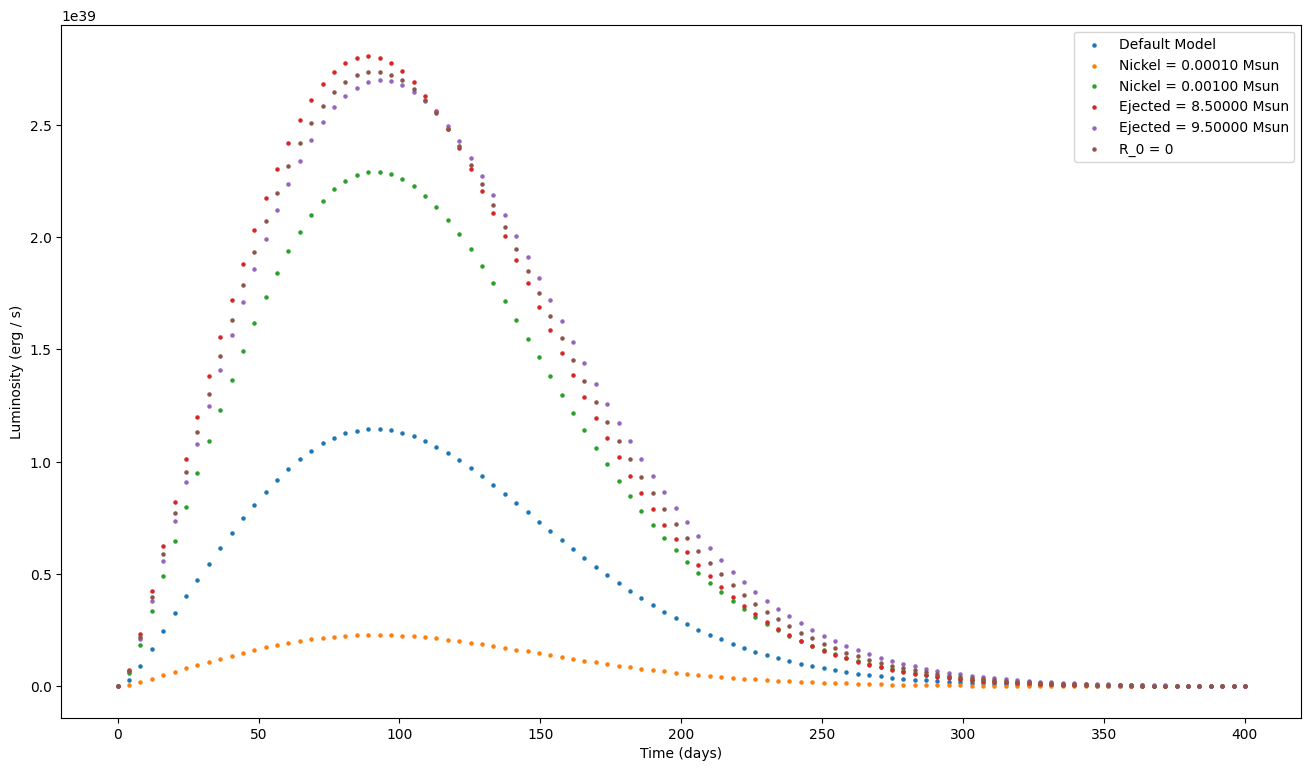

In [102]:
# Define Initial Parameters for modeling the Supernova's light curve.
Star_Mass = 10 * u.M_sun
Star_Radius = 10 * u.R_sun
M_Ni = 0.00005 * Star_Mass
M_Ni = M_Ni.to(u.g)
M_ej = 0.9 * Star_Mass
M_ej = M_ej.to(u.g)
R_0 = 1 * Star_Radius
R_0 = R_0.to(u.cm)
v = 4500 * u.km / u.s
v = v.to(u.cm / u.s)
opacity = 0.4 * u.cm**2 / u.g
beta = 13.7 
E_Ni = 3.9 * 1e10 * u.erg / u.g
E_Co = 6.8 * 1e9 * u.erg / u.g
T_Co = 111.3 * u.d
T_Co = T_Co.to(u.s)
T_Ni = 8.8 * u.d
T_Ni = T_Ni.to(u.s)
days = 400
n = 100

# Initializing the figure so that we can plot multiple light curves.
plt.figure(figsize=(16,9))

# Creating the luminosity array for later. Also making the time array.
luminosity_array = []
time_array = np.linspace(0,days,n)

# Calculating the default model.
for t in time_array * u.d:
    td = diffusion_calc(M_ej, beta, opacity, v).to(u.s)
    t_sec = t.to(u.s)
    L = luminosity(t_sec, M_Ni, R_0, v, td, T_Ni, T_Co, E_Ni, E_Co)
    luminosity_array.append(L[0])
    print(f"At time {t.to(u.d):.2f}, the luminosity is {L[0]:.2e}")
plt.scatter(time_array, luminosity_array, s=5, label = f"Default Model")

# Higher and lower Nickel mass.
for nickel_mass in [0.00001 * Star_Mass, 0.0001 * Star_Mass]:
    M_Ni = nickel_mass.to(u.g)
    luminosity_array = []
    for t in time_array * u.d:
        td = diffusion_calc(M_ej, beta, opacity, v).to(u.s)
        t_sec = t.to(u.s)
        L = luminosity(t_sec, M_Ni, R_0, v, td, T_Ni, T_Co, E_Ni, E_Co)
        luminosity_array.append(L[0])
        print(f"At time {t.to(u.d):.2f}, the luminosity is {L[0]:.2e}")
    plt.scatter(time_array, luminosity_array, s=5, label = f"Nickel = {nickel_mass.to(u.M_sun).value:.5f} Msun")

# Resetting the Nickel mass to default, so that the next loop has default parameters.
M_Ni = 0.00012 * Star_Mass
M_Ni = M_Ni.to(u.g)

for ejected_mass in [0.85 * Star_Mass, 0.95 * Star_Mass]:
    M_ej = ejected_mass.to(u.g)
    luminosity_array = []
    for t in time_array * u.d:
        td = diffusion_calc(M_ej, beta, opacity, v).to(u.s)
        t_sec = t.to(u.s)
        L = luminosity(t_sec, M_Ni, R_0, v, td, T_Ni, T_Co, E_Ni, E_Co)
        luminosity_array.append(L[0])
        print(f"At time {t.to(u.d):.2f}, the luminosity is {L[0]:.2e}")
    plt.scatter(time_array, luminosity_array, s=5, label = f"Ejected = {ejected_mass.to(u.M_sun).value:.5f} Msun")

# Resetting the Ejected mass to default, so that the final loop has default
M_ej = 0.9 * Star_Mass
M_ej = M_ej.to(u.g)
R_0 = 0 * Star_Radius
R_0 = R_0.to(u.cm)
luminosity_array = []
for t in time_array * u.d:
    td = diffusion_calc(M_ej, beta, opacity, v).to(u.s)
    t_sec = t.to(u.s)
    L = luminosity(t_sec, M_Ni, R_0, v, td, T_Ni, T_Co, E_Ni, E_Co)
    luminosity_array.append(L[0])
    print(f"At time {t.to(u.d):.2f}, the luminosity is {L[0]:.2e}")
plt.scatter(time_array, luminosity_array, s=5, label = f"R_0 = 0")

plt.legend()
plt.ylabel("Luminosity (erg / s)")
plt.xlabel("Time (days)")

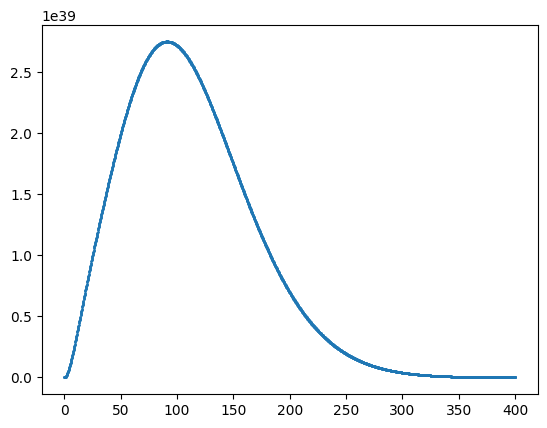

In [85]:
plt.scatter(time_array, luminosity_array, s=1, label = "M=10Msun")

<Quantity 3.58304677e+38 erg / s>